**------Air Quality and Acute Respiratory Infection (ARI) in Children Across Indian States-------**

**An Exploratory Data Analysis combining CPCB air quality data (2010–2023) with NFHS-6 (2023–24) health survey data**

In [3]:
# Objective: Examine whether state-level outdoor air pollution (PM2.5) correlates with
# childhood ARI (Acute Respiratory Infection) prevalence — testing the common assumption
# that highly polluted states/cities show worse respiratory health outcomes.

In [4]:
# All libraries needed for this notebook, imported once at the top
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import re
from google.colab import drive, files

## Step 1: Load Air Quality Data
Mounting Google Drive and unzipping the CPCB station-level dataset (442 usable stations, 2010–2023)

In [5]:
# Mount Google Drive to access the uploaded zip file
drive.mount('/content/drive')


Mounted at /content/drive


In [6]:
# Unzip the raw station data (one CSV per monitoring station)
!unzip -q "/content/drive/MyDrive/Time_Series_Data.zip" -d /content/Time_Series_Data

correct_path = "/content/Time_Series_Data/Time_Series_Data"
files_list = os.listdir(correct_path)
print(f"Total files found: {len(files_list)}")

Total files found: 453


## Step 2: Map Station Codes to States
Filenames encode a 2-letter state code (e.g. AP001.csv = Andhra Pradesh, station 1).
This dictionary translates each code to its full state name.

In [7]:
# Lookup table: 2-letter filename prefix -> full state name
state_code_map = {
    'AP':'Andhra Pradesh','AR':'Arunachal Pradesh','AS':'Assam','BR':'Bihar',
    'CH':'Chandigarh','CT':'Chhattisgarh','CG':'Chhattisgarh','DL':'NCT of Delhi','GA':'Goa',
    'GJ':'Gujarat','HR':'Haryana','HP':'Himachal Pradesh','JH':'Jharkhand',
    'JK':'Jammu and Kashmir','KA':'Karnataka','KL':'Kerala','MP':'Madhya Pradesh',
    'MH':'Maharashtra','MN':'Manipur','ML':'Meghalaya','MZ':'Mizoram',
    'NL':'Nagaland','OD':'Odisha','OR':'Odisha','PB':'Punjab','PY':'Puducherry',
    'RJ':'Rajasthan','SK':'Sikkim','TN':'Tamil Nadu','TG':'Telangana','TS':'Telangana',
    'TR':'Tripura','UP':'Uttar Pradesh','UK':'Uttarakhand','UT':'Uttarakhand',
    'WB':'West Bengal','DN':'Dadra & Nagar Haveli and Daman & Diu',
    'LD':'Lakshadweep','AN':'Andaman and Nicobar Islands','LA':'Ladakh'
}

## Step 3: Process All Station Files
For each station file: extract its state from the filename, then compute average
PM2.5 and PM10. Using PM2.5 as the primary pollution indicator (rather than a
composite AQI) since it has the strongest documented link to respiratory illness
specifically, which is most relevant to this analysis. Some stations are missing
pollutant columns entirely — these are handled gracefully rather than crashing the loop.

In [8]:
records = []   # successfully processed stations
errors = []    # files that failed or had unmapped state codes

for fname in files_list:
    if not fname.endswith('.csv'):
        continue

    # Extract the 2-letter state code from the start of the filename
    code = re.match(r'([A-Z]{2})', fname)
    if not code:
        errors.append(fname)
        continue

    state = state_code_map.get(code.group(1), None)
    if state is None:
        errors.append(fname)
        continue

    try:
        df = pd.read_csv(f"{correct_path}/{fname}")
        # Some stations don't record every pollutant -- check before averaging
        pm25_mean = df['PM2.5 (ug/m3)'].mean() if 'PM2.5 (ug/m3)' in df.columns else None
        pm10_mean = df['PM10 (ug/m3)'].mean() if 'PM10 (ug/m3)' in df.columns else None

        records.append({
            'file': fname,
            'state': state,
            'pm25_mean': pm25_mean,
            'pm10_mean': pm10_mean,
            'row_count': len(df)
        })
    except Exception as e:
        errors.append((fname, str(e)))

station_df = pd.DataFrame(records)
print(f"Processed: {len(station_df)} stations")
print(f"Unmapped/failed: {len(errors)}")
print(errors[:10])

Processed: 453 stations
Unmapped/failed: 0
[]


## Step 4: Aggregate Station Data to State Level
Averaging all stations within each state to get one PM2.5/PM10 value per state,
so it can be merged with state-level health data. Station count per state is
tracked too -- states with very few stations (as low as 1) have less reliable
averages, and this is noted as a limitation later.

In [9]:
state_pm_df = station_df.groupby('state')[['pm25_mean', 'pm10_mean']].mean().reset_index()
state_pm_df['station_count'] = station_df.groupby('state').size().values
print(state_pm_df.sort_values('pm25_mean', ascending=False))

                state   pm25_mean   pm10_mean  station_count
18       NCT of Delhi  108.772210  216.636240             40
3               Bihar   96.548468  193.150987             35
2               Assam   85.841695  167.645168              9
10          Jharkhand   76.837822  146.067866              2
7             Haryana   76.209160  153.765483             30
20             Odisha   73.183465  152.610933             12
28      Uttar Pradesh   72.578828  145.412612             57
8    Himachal Pradesh   67.764348  158.322855              1
27            Tripura   59.352325  101.471170              2
4          Chandigarh   58.923754  114.410762              3
6             Gujarat   58.857086  110.070352             17
30        West Bengal   57.009372  113.291706             14
13     Madhya Pradesh   52.015404  122.294238             22
22             Punjab   51.191564  113.261433              8
14        Maharashtra   49.265557  105.257292             41
23          Rajasthan   

## Step 5: Load Health Data (NFHS-6)
NFHS-6 (2023–24) is the most recent national health survey, released May 2026.
The ARI (Acute Respiratory Infection) indicator for children under 5 was extracted
from the official 182-page government PDF fact sheet report ahead of this notebook.

In [10]:
uploaded = files.upload()  # upload nfhs6_ari_by_state.csv here

Saving nfhs6_ari_by_state.csv to nfhs6_ari_by_state.csv


In [11]:
nfhs_df = pd.read_csv("nfhs6_ari_by_state.csv")
print(nfhs_df.head())

               state  ari_urban_nfhs6 ari_rural_nfhs6  ari_total_nfhs6  \
0     Andhra Pradesh              0.7             1.1              1.0   
1  Arunachal Pradesh              0.2             0.7              0.5   
2              Assam              0.9             0.6              0.6   
3              Bihar              2.4             3.3              3.2   
4       Chhattisgarh              0.5             0.8              0.7   

   ari_total_nfhs5  
0              2.4  
1              2.1  
2              2.5  
3              3.5  
4              1.5  


## Step 6: Merge Air Quality and Health Data
Inner join on state name. This drops Manipur (excluded from NFHS-6 fieldwork)
and 5 small union territories with no AQI monitoring stations in this dataset
-- reducing the final analysis to 30 states. This is a limitation, noted explicitly
rather than hidden.

In [13]:
merged_df = pd.merge(state_pm_df, nfhs_df, on='state', how='inner')
print(f"Merged states: {len(merged_df)}")

aqi_states = set(state_pm_df['state'])
nfhs_states = set(nfhs_df['state'])
print("In AQI but not NFHS:", aqi_states - nfhs_states)
print("In NFHS but not AQI:", nfhs_states - aqi_states)

merged_df


Merged states: 30
In AQI but not NFHS: {'Manipur'}
In NFHS but not AQI: {'Lakshadweep', 'Andaman and Nicobar Islands', 'Dadra & Nagar Haveli and Daman & Diu', 'Ladakh', 'Goa'}


,state,pm25_mean,pm10_mean,station_count,ari_urban_nfhs6,ari_rural_nfhs6,ari_total_nfhs6,ari_total_nfhs5
0,Andhra Pradesh,42.173198,77.986463,10,0.7,1.1,1.0,2.4
1,Arunachal Pradesh,21.330971,55.787106,1,0.2,0.7,0.5,2.1
2,Assam,85.841695,167.645168,9,0.9,0.6,0.6,2.5
3,Bihar,96.548468,193.150987,35,2.4,3.3,3.2,3.5
4,Chandigarh,58.923754,114.410762,3,1.1,*,1.0,0.3
5,Chhattisgarh,36.389439,87.247633,14,0.5,0.8,0.7,1.5
6,Gujarat,58.857086,110.070352,17,0.8,0.7,0.8,1.0
7,Haryana,76.209160,153.765483,30,0.7,1.4,1.2,2.3
8,Himachal Pradesh,67.764348,158.322855,1,0.9,1.0,1.0,1.5
9,Jammu and Kashmir,28.526610,84.165988,1,1.1,2.3,2.1,3.8


## Step 7: Correlation Analysis
Testing whether PM2.5 and childhood ARI actually move together across states.


In [14]:
correlation = merged_df['pm25_mean'].corr(merged_df['ari_total_nfhs6'])
print(f"Correlation between PM2.5 and current ARI: {correlation:.3f}")

correlation_prev = merged_df['pm25_mean'].corr(merged_df['ari_total_nfhs5'])
print(f"Correlation between PM2.5 and previous-round ARI: {correlation_prev:.3f}")

# Correlation = 0.354 (weak-positive): PM2.5 explains only ~12% of variation in ARI
# (r-squared = 0.354^2 ≈ 0.125). Delhi (highest PM2.5, low ARI) and Kerala
# (low PM2.5, high ARI) are the clearest counter-examples -- challenging the
# assumption that outdoor pollution is the dominant driver of childhood ARI.

merged_df[['state','pm25_mean','ari_total_nfhs6']].sort_values('pm25_mean', ascending=False)

Correlation between PM2.5 and current ARI: 0.352
Correlation between PM2.5 and previous-round ARI: 0.282


,state,pm25_mean,ari_total_nfhs6
17,NCT of Delhi,108.772210,1.3
3,Bihar,96.548468,3.2
2,Assam,85.841695,0.6
10,Jharkhand,76.837822,2.3
7,Haryana,76.209160,1.2
19,Odisha,73.183465,1.2
27,Uttar Pradesh,72.578828,2.6
8,Himachal Pradesh,67.764348,1.0
26,Tripura,59.352325,1.3
4,Chandigarh,58.923754,1.0


## Step 8: Visualization

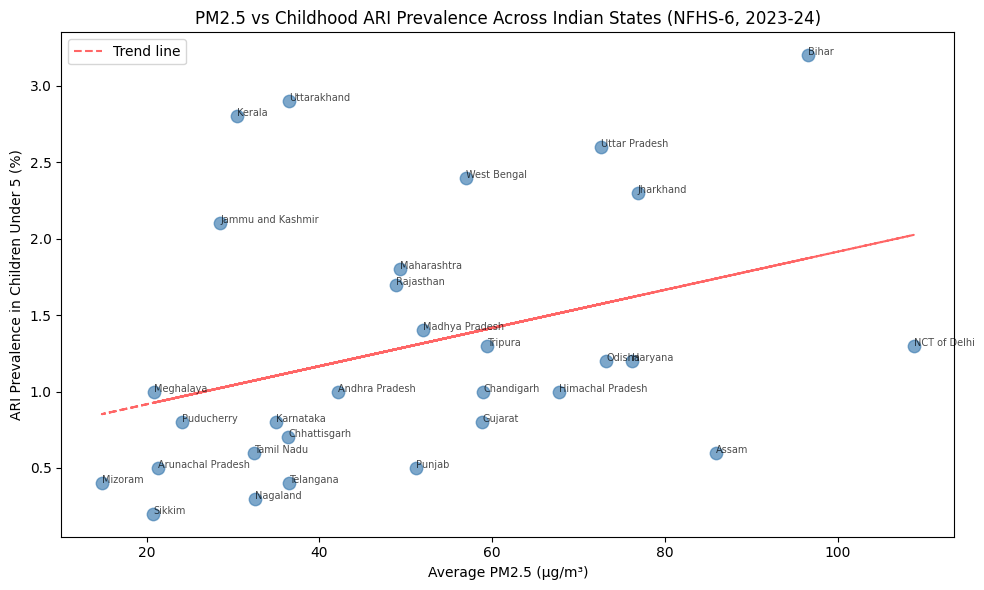

In [15]:
plt.figure(figsize=(10,6))
plt.scatter(merged_df['pm25_mean'], merged_df['ari_total_nfhs6'], color='steelblue', s=80, alpha=0.7)

for i, row in merged_df.iterrows():
    plt.annotate(row['state'], (row['pm25_mean'], row['ari_total_nfhs6']), fontsize=7, alpha=0.7)

# Trend line to visualize the weak-positive relationship
z = np.polyfit(merged_df['pm25_mean'], merged_df['ari_total_nfhs6'], 1)
p = np.poly1d(z)
plt.plot(merged_df['pm25_mean'], p(merged_df['pm25_mean']), "r--", alpha=0.6, label='Trend line')

plt.xlabel('Average PM2.5 (µg/m³)')
plt.ylabel('ARI Prevalence in Children Under 5 (%)')
plt.title('PM2.5 vs Childhood ARI Prevalence Across Indian States (NFHS-6, 2023-24)')
plt.legend()
plt.tight_layout()
plt.savefig('pm25_vs_ari_scatter.png', dpi=150)
plt.show()

## Step 9: Exporting Final Files for GitHub

In [16]:
merged_df.to_csv('final_merged_pm25_ari.csv', index=False)

files.download('final_merged_pm25_ari.csv')
files.download('pm25_vs_ari_scatter.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Conclusion

PM2.5 shows only a **weak positive correlation (r = 0.35)** with childhood ARI
prevalence across 30 Indian states — meaning ambient outdoor pollution explains
roughly 12% of the variation in respiratory illness. This challenges the common
assumption that high-pollution states/cities automatically show worse respiratory
health outcomes.

**Notable outliers:**
- **NCT of Delhi** — highest PM2.5 (108.8 µg/m³) but relatively low ARI (1.3%)
- **Kerala** — low PM2.5 (30.4 µg/m³) but among the highest ARI (2.8%)
- **Bihar** — the one state where the assumption holds (high PM2.5, highest ARI)

**Interpretation:** Outdoor pollution is likely not the dominant driver of childhood
respiratory illness at a state level. Indoor air pollution, healthcare access/reporting
differences, humidity, population density, and nutrition likely play a larger combined role.

**Limitations:**
- AQI aggregated from station to state level, masking intra-state variation
- Station count per state ranges from 1 to 56 — uneven reliability
- NFHS-6 excluded Manipur; 5 UTs had no matching AQI stations (final sample: 30 states)
- Correlation ≠ causation; no controls for confounders (income, density, healthcare access)